In [ ]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.13

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 22.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


In [ ]:
!unzip -q "/content/drive/MyDrive/인공지능종합설계/ksl_dataset/ksl_video/ksl_video_test.zip" -d "/content/ksl_video_test"

In [ ]:
import os, glob, cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import mediapipe as mp
from google.colab.patches import cv2_imshow

In [ ]:
import os
import glob

# ===== 설정 =====
ROOT_DIR = "/content/ksl_video_test"   # mp3 파일들이 들어있는 폴더
OUT_DIR = "/content/holistic_results"
FPS = 30

os.makedirs(OUT_DIR, exist_ok=True)

video_files = sorted(glob.glob(os.path.join(ROOT_DIR, "*.mp4")))

print("mp4 files:", len(video_files))
print(video_files[:5])

mp3 files: 118
['/content/ksl_video_test/00_08.mp4', '/content/ksl_video_test/00_17.mp4', '/content/ksl_video_test/00_24.mp4', '/content/ksl_video_test/00_44.mp4', '/content/ksl_video_test/00_54.mp4']


In [ ]:
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

def landmarks_to_array(landmarks, num_points, image_w, image_h):
    """
    return shape: (num_points, 4)
    columns: x_pixel, y_pixel, z, visibility/presence
    """
    arr = np.full((num_points, 4), np.nan, dtype=np.float32)

    if landmarks is None:
        return arr

    for i, lm in enumerate(landmarks.landmark):
        score = getattr(lm, "visibility", np.nan)
        arr[i] = [
            lm.x * image_w,
            lm.y * image_h,
            lm.z,
            score
        ]

    return arr

In [ ]:
def process_one_video(video_path):
    video_name = os.path.splitext(os.path.basename(video_path))[0]

    video_out_dir = os.path.join(OUT_DIR, video_name)
    overlay_dir = os.path.join(video_out_dir, "overlay")
    os.makedirs(overlay_dir, exist_ok=True)

    pose_list = []
    left_hand_list = []
    right_hand_list = []
    face_list = []
    summary_rows = []

    cap = cv2.VideoCapture(video_path)

    holistic = mp_holistic.Holistic(
        static_image_mode=False,   # 🔥 중요 (영상이면 False)
        model_complexity=2,
        smooth_landmarks=True,     # 영상이면 True 추천
        refine_face_landmarks=False,
        min_detection_confidence=0.3,
        min_tracking_confidence=0.3
    )

    # ===== 색 정의 =====
    pose_style = mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2)
    left_hand_style = mp_drawing.DrawingSpec(color=(255,0,0), thickness=2, circle_radius=2)
    right_hand_style = mp_drawing.DrawingSpec(color=(0,0,255), thickness=2, circle_radius=2)
    face_style = mp_drawing.DrawingSpec(color=(255,255,255), thickness=1, circle_radius=1)

    idx = 0

    while cap.isOpened():
        ret, image_bgr = cap.read()
        if not ret:
            break

        h, w = image_bgr.shape[:2]
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        result = holistic.process(image_rgb)

        # ===== landmark 변환 =====
        pose_arr = landmarks_to_array(result.pose_landmarks, 33, w, h)
        left_hand_arr = landmarks_to_array(result.left_hand_landmarks, 21, w, h)
        right_hand_arr = landmarks_to_array(result.right_hand_landmarks, 21, w, h)
        face_arr = landmarks_to_array(result.face_landmarks, 468, w, h)

        pose_list.append(pose_arr)
        left_hand_list.append(left_hand_arr)
        right_hand_list.append(right_hand_arr)
        face_list.append(face_arr)

        # ===== detection 여부 =====
        pose_detected = result.pose_landmarks is not None
        left_hand_detected = result.left_hand_landmarks is not None
        right_hand_detected = result.right_hand_landmarks is not None
        face_detected = result.face_landmarks is not None

        mean_pose_visibility = np.nanmean(pose_arr[:, 3])

        summary_rows.append({
            "video": video_name,
            "frame_idx": idx,
            "file": f"{idx:06d}.jpg",
            "pose_detected": pose_detected,
            "left_hand_detected": left_hand_detected,
            "right_hand_detected": right_hand_detected,
            "face_detected": face_detected,
            "mean_pose_visibility": mean_pose_visibility
        })

        # ===== overlay =====
        overlay = image_bgr.copy()

        if result.pose_landmarks:
            mp_drawing.draw_landmarks(
                overlay, result.pose_landmarks,
                mp_holistic.POSE_CONNECTIONS,
                pose_style, pose_style
            )

        if result.left_hand_landmarks:
            mp_drawing.draw_landmarks(
                overlay, result.left_hand_landmarks,
                mp_holistic.HAND_CONNECTIONS,
                left_hand_style, left_hand_style
            )

        if result.right_hand_landmarks:
            mp_drawing.draw_landmarks(
                overlay, result.right_hand_landmarks,
                mp_holistic.HAND_CONNECTIONS,
                right_hand_style, right_hand_style
            )

        if result.face_landmarks:
            mp_drawing.draw_landmarks(
                overlay, result.face_landmarks,
                mp_holistic.FACEMESH_TESSELATION,
                face_style, face_style
            )

        cv2.imwrite(os.path.join(overlay_dir, f"{idx:06d}.jpg"), overlay)

        idx += 1

    cap.release()
    holistic.close()

    # ===== numpy 저장 =====
    pose_np = np.stack(pose_list) if pose_list else np.empty((0, 33, 4))
    left_hand_np = np.stack(left_hand_list) if left_hand_list else np.empty((0, 21, 4))
    right_hand_np = np.stack(right_hand_list) if right_hand_list else np.empty((0, 21, 4))
    face_np = np.stack(face_list) if face_list else np.empty((0, 468, 4))

    np.save(os.path.join(video_out_dir, "pose_33.npy"), pose_np)
    np.save(os.path.join(video_out_dir, "left_hand_21.npy"), left_hand_np)
    np.save(os.path.join(video_out_dir, "right_hand_21.npy"), right_hand_np)
    np.save(os.path.join(video_out_dir, "face_468.npy"), face_np)

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(os.path.join(video_out_dir, "summary.csv"), index=False)

    # ===== overlay mp4 생성 =====
    if idx > 0:
        first_img = cv2.imread(os.path.join(overlay_dir, "000000.jpg"))
        if first_img is not None:
            h, w = first_img.shape[:2]
            video_out_path = os.path.join(video_out_dir, "overlay.mp4")

            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            writer = cv2.VideoWriter(video_out_path, fourcc, FPS, (w, h))

            for i in range(idx):
                img = cv2.imread(os.path.join(overlay_dir, f"{i:06d}.jpg"))
                if img is not None:
                    writer.write(img)

            writer.release()

    return summary_df

In [ ]:
all_dfs = []

for video_path in video_files[:50]:
    df = process_one_video(video_path)
    all_dfs.append(df)
    print(video_path)
    # print(df)

merged_df = pd.concat(all_dfs, ignore_index=True)

merged_df.to_csv(os.path.join(OUT_DIR, "all_summary.csv"), index=False)

merged_df

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


/content/ksl_video_test/00_08.mp4
/content/ksl_video_test/00_17.mp4
/content/ksl_video_test/00_24.mp4
/content/ksl_video_test/00_44.mp4
/content/ksl_video_test/00_54.mp4
/content/ksl_video_test/00_56.mp4
/content/ksl_video_test/01_07.mp4
/content/ksl_video_test/01_34.mp4
/content/ksl_video_test/01_38.mp4
/content/ksl_video_test/01_39.mp4
/content/ksl_video_test/01_62.mp4
/content/ksl_video_test/01_68.mp4
/content/ksl_video_test/02_14.mp4
/content/ksl_video_test/02_21.mp4
/content/ksl_video_test/02_31.mp4
/content/ksl_video_test/02_59.mp4
/content/ksl_video_test/02_61.mp4
/content/ksl_video_test/02_76.mp4
/content/ksl_video_test/03_03.mp4
/content/ksl_video_test/03_15.mp4
/content/ksl_video_test/03_24.mp4
/content/ksl_video_test/03_43.mp4
/content/ksl_video_test/03_63.mp4
/content/ksl_video_test/03_71.mp4
/content/ksl_video_test/04_03.mp4
/content/ksl_video_test/04_34.mp4
/content/ksl_video_test/04_56.mp4
/content/ksl_video_test/04_67.mp4
/content/ksl_video_test/05_27.mp4
/content/ksl_v

,video,frame_idx,file,pose_detected,left_hand_detected,right_hand_detected,face_detected,mean_pose_visibility
0,00_08,0,000000.jpg,True,True,True,True,0.667244
1,00_08,1,000001.jpg,True,True,True,True,0.674510
2,00_08,2,000002.jpg,True,True,True,True,0.680082
3,00_08,3,000003.jpg,True,True,True,True,0.685210
4,00_08,4,000004.jpg,True,True,True,True,0.689859
...,...,...,...,...,...,...,...,...
4278,09_49,95,000095.jpg,True,False,False,True,0.416982
4279,09_49,96,000096.jpg,True,False,False,True,0.416328
4280,09_49,97,000097.jpg,True,False,False,True,0.415871
4281,09_49,98,000098.jpg,True,False,False,True,0.415348


In [ ]:
!unzip /content/holistic_results_zip.zip -d /content/holistic_results

In [ ]:
!zip -r /content/holistic_results.zip /content/holistic_results

  adding: content/holistic_results/ (stored 0%)
  adding: content/holistic_results/left_hand_21.npy (deflated 42%)
  adding: content/holistic_results/07_54/ (stored 0%)
  adding: content/holistic_results/07_54/left_hand_21.npy (deflated 75%)
  adding: content/holistic_results/07_54/overlay.mp4 (deflated 3%)
  adding: content/holistic_results/07_54/face_468.npy (deflated 26%)
  adding: content/holistic_results/07_54/pose_33.npy (deflated 8%)
  adding: content/holistic_results/07_54/right_hand_21.npy (deflated 73%)
  adding: content/holistic_results/07_54/summary.csv (deflated 78%)
  adding: content/holistic_results/07_54/overlay/ (stored 0%)
  adding: content/holistic_results/07_54/overlay/000046.jpg (deflated 0%)
  adding: content/holistic_results/07_54/overlay/000084.jpg (deflated 0%)
  adding: content/holistic_results/07_54/overlay/000052.jpg (deflated 0%)
  adding: content/holistic_results/07_54/overlay/000087.jpg (deflated 0%)
  adding: content/holistic_results/07_54/overlay/000051

In [ ]:
all_summary_df = pd.read_csv("/content/holistic_results/all_summary_df.csv")
all_summary_df

,video,frame_idx,file,pose_detected,left_hand_detected,right_hand_detected,face_detected,mean_pose_visibility
0,00_08,0,img_00001.jpg,True,False,True,True,0.680089
1,00_08,1,img_00002.jpg,True,False,True,True,0.714069
2,00_08,2,img_00003.jpg,True,False,True,True,0.714069
3,00_08,3,img_00004.jpg,True,False,True,True,0.707054
4,00_08,4,img_00005.jpg,True,False,True,True,0.676449
...,...,...,...,...,...,...,...,...
4364,09_49,98,img_00099.jpg,True,False,False,True,0.489778
4365,09_49,99,img_00100.jpg,True,False,False,True,0.501504
4366,09_49,100,img_00101.jpg,True,False,False,True,0.483462
4367,09_49,101,img_00102.jpg,True,False,False,True,0.502561


In [ ]:
import pandas as pd

is_with_one_hand = pd.read_csv('/content/is_with_one_hand.csv')

print(is_with_one_hand.head())

   video  hand_flag
0  00_08          0
1  00_17          1
2  00_24          1
3  00_44          1
4  00_54          0


In [ ]:
# 비디오 기준으로 merge (컬럼명은 상황에 맞게 수정하세요)
all_summary_df = merged_df

merged = all_summary_df.merge(
    is_with_one_hand,
    on='video',   # 공통 키 (예: 'video', 'video_id' 등)
    how='left'
)
merged

,video,frame_idx,file,pose_detected,left_hand_detected,right_hand_detected,face_detected,mean_pose_visibility,hand_flag
0,00_08,0,000000.jpg,True,True,True,True,0.667244,0
1,00_08,1,000001.jpg,True,True,True,True,0.674510,0
2,00_08,2,000002.jpg,True,True,True,True,0.680082,0
3,00_08,3,000003.jpg,True,True,True,True,0.685210,0
4,00_08,4,000004.jpg,True,True,True,True,0.689859,0
...,...,...,...,...,...,...,...,...,...
4278,09_49,95,000095.jpg,True,False,False,True,0.416982,0
4279,09_49,96,000096.jpg,True,False,False,True,0.416328,0
4280,09_49,97,000097.jpg,True,False,False,True,0.415871,0
4281,09_49,98,000098.jpg,True,False,False,True,0.415348,0


In [ ]:
# 맨 뒤 컬럼 (is_with_one_hand 값)
flag_col = is_with_one_hand.columns[-1]

# 조건 적용
# 1 → left hand detected = None
merged.loc[merged[flag_col] == 1, 'left_hand_detected'] = None

# 2 → right hand detected = None
merged.loc[merged[flag_col] == 2, 'right_hand_detected'] = None

# 0 → 그대로 유지 (따로 처리 필요 없음)

# 필요 없으면 flag 컬럼 제거
merged = merged.drop(columns=[flag_col, "mean_pose_visibility"])

# 결과 확인
print(merged.head())

left_mean = merged['left_hand_detected'].mean()
right_mean = merged['right_hand_detected'].mean()

merged.to_csv("/content/all_summary_df.csv", index=True)

   video  frame_idx        file  pose_detected left_hand_detected  \
0  00_08          0  000000.jpg           True               True   
1  00_08          1  000001.jpg           True               True   
2  00_08          2  000002.jpg           True               True   
3  00_08          3  000003.jpg           True               True   
4  00_08          4  000004.jpg           True               True   

  right_hand_detected  face_detected  
0                True           True  
1                True           True  
2                True           True  
3                True           True  
4                True           True  


/tmp/ipykernel_10984/2381816746.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  merged.loc[merged[flag_col] == 1, 'left_hand_detected'] = None
/tmp/ipykernel_10984/2381816746.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  merged.loc[merged[flag_col] == 2, 'right_hand_detected'] = None


#통계

img -> video 입력 ) hand : 0.25 -> 0.57

In [ ]:
# ===== 전체 detection rate 확인 ===== # frame, video 합쳐서 평균 (프레임 내에 Nan이 아닌 손이 한번이라도 나옴)
print("pose detection rate:", merged["pose_detected"].mean())
print("left hand detection rate:", merged["left_hand_detected"].mean())
print("right hand detection rate:", merged["right_hand_detected"].mean())
print("face detection rate:", merged["face_detected"].mean())

pose detection rate: 1.0
left hand detection rate: 0.576235978396344
right hand detection rate: 0.579127042184833
face detection rate: 0.9964977819285548


In [ ]:
# ===== 비디오별 detection rate ===== #각 video 내에 frame 평균
video_stats = merged.groupby("video").agg({
    "pose_detected": "mean",
    "left_hand_detected": "mean",
    "right_hand_detected": "mean",
    "face_detected": "mean",
}).reset_index()

video_stats_hand = video_stats[["video","left_hand_detected", "right_hand_detected"]]
video_stats_hand

,video,left_hand_detected,right_hand_detected
0,00_08,0.84375,0.854167
1,00_17,NaN,0.945055
2,00_24,NaN,0.877193
3,00_44,NaN,0.960396
4,00_54,0.863158,0.905263
5,00_56,NaN,0.846939
6,01_07,NaN,0.56962
7,01_34,NaN,0.483146
8,01_38,0.544444,0.555556
9,01_39,0.397959,0.540816


In [ ]:
#프레임별 detection rate
video_stats_per_frame = merged.groupby("frame_idx").agg({
    "pose_detected": "mean",
    "left_hand_detected": "mean",
    "right_hand_detected": "mean",
    "face_detected": "mean",
}).reset_index()
video_stats_per_frame
#video_stats_per_frame.to_csv("/content/video_stats_per_frame.csv", index=True)

,frame_idx,pose_detected,left_hand_detected,right_hand_detected,face_detected
0,0,1.0,0.178571,0.212766,1.0
1,1,1.0,0.285714,0.255319,1.0
2,2,1.0,0.285714,0.297872,1.0
3,3,1.0,0.285714,0.319149,1.0
4,4,1.0,0.357143,0.382979,1.0
...,...,...,...,...,...
137,137,1.0,0.0,0.0,1.0
138,138,1.0,0.0,0.0,1.0
139,139,1.0,0.0,0.0,1.0
140,140,1.0,0.0,0.0,1.0


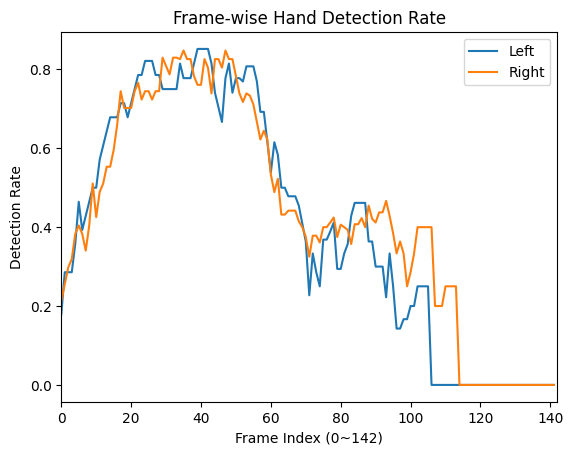

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    video_stats_per_frame["frame_idx"],
    video_stats_per_frame["left_hand_detected"],
    label="Left"
)

plt.plot(
    video_stats_per_frame["frame_idx"],
    video_stats_per_frame["right_hand_detected"],
    label="Right"
)

plt.xlabel("Frame Index (0~142)")
plt.ylabel("Detection Rate")
plt.title("Frame-wise Hand Detection Rate")
plt.legend()

plt.xlim(0, 142)  # x축 범위 고정

plt.show()

프레임 100이상 구간 제거하고 다시 통계

In [ ]:
merged_front = merged[merged["frame_idx"] < 100]
merged_front

,video,frame_idx,file,pose_detected,left_hand_detected,right_hand_detected,face_detected
0,00_08,0,000000.jpg,True,True,True,True
1,00_08,1,000001.jpg,True,True,True,True
2,00_08,2,000002.jpg,True,True,True,True
3,00_08,3,000003.jpg,True,True,True,True
4,00_08,4,000004.jpg,True,True,True,True
...,...,...,...,...,...,...,...
4278,09_49,95,000095.jpg,True,False,False,True
4279,09_49,96,000096.jpg,True,False,False,True
4280,09_49,97,000097.jpg,True,False,False,True
4281,09_49,98,000098.jpg,True,False,False,True


In [ ]:
# ===== 전체 detection rate 확인 ===== # frame, video 합쳐서 평균 (프레임 내에 Nan이 아닌 손이 한번이라도 나옴)
print("pose detection rate:", merged_front["pose_detected"].mean())
print("left hand detection rate:", merged_front["left_hand_detected"].mean())
print("right hand detection rate:", merged_front["right_hand_detected"].mean())
print("face detection rate:", merged_front["face_detected"].mean())

pose detection rate: 1.0
left hand detection rate: 0.6017429193899783
right hand detection rate: 0.5923502767991947
face detection rate: 0.996390760346487


In [ ]:
# ===== 비디오별 detection rate ===== #각 video 내에 frame 평균
video_stats_front = merged_front.groupby("video").agg({
    "pose_detected": "mean",
    "left_hand_detected": "mean",
    "right_hand_detected": "mean",
    "face_detected": "mean",
}).reset_index()

video_stats_front_hand = video_stats_front[["video","left_hand_detected", "right_hand_detected"]]
video_stats_front_hand

,video,left_hand_detected,right_hand_detected
0,00_08,0.84375,0.854167
1,00_17,NaN,0.945055
2,00_24,NaN,0.86
3,00_44,NaN,0.97
4,00_54,0.863158,0.905263
5,00_56,NaN,0.846939
6,01_07,NaN,0.56962
7,01_34,NaN,0.483146
8,01_38,0.544444,0.555556
9,01_39,0.397959,0.540816


In [ ]:
#프레임별 detection rate
video_stats_per_frame_front = merged_front.groupby("frame_idx").agg({
    "pose_detected": "mean",
    "left_hand_detected": "mean",
    "right_hand_detected": "mean",
    "face_detected": "mean",
}).reset_index()

video_stats_per_frame_front

,frame_idx,pose_detected,left_hand_detected,right_hand_detected,face_detected
0,0,1.0,0.178571,0.212766,1.0
1,1,1.0,0.285714,0.255319,1.0
2,2,1.0,0.285714,0.297872,1.0
3,3,1.0,0.285714,0.319149,1.0
4,4,1.0,0.357143,0.382979,1.0
...,...,...,...,...,...
95,95,1.0,0.25,0.384615,1.0
96,96,1.0,0.142857,0.333333,1.0
97,97,1.0,0.142857,0.363636,1.0
98,98,1.0,0.166667,0.333333,1.0


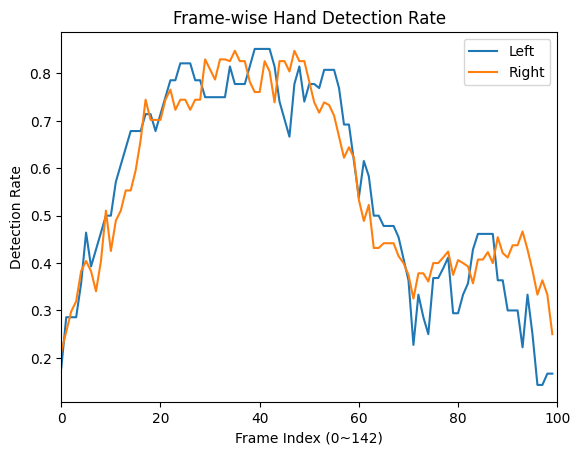

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    video_stats_per_frame_front["frame_idx"],
    video_stats_per_frame_front["left_hand_detected"],
    label="Left"
)

plt.plot(
    video_stats_per_frame_front["frame_idx"],
    video_stats_per_frame_front["right_hand_detected"],
    label="Right"
)

plt.xlabel("Frame Index (0~142)")
plt.ylabel("Detection Rate")
plt.title("Frame-wise Hand Detection Rate")
plt.legend()

plt.xlim(0, 100)  # x축 범위 고정

plt.show()

- 한 손으로 하는 수어는 그 반대 손 detection rate에서 제거
- 수어 하지 않는 뒷부분 프레임들 detection rate에서 제거

<frame단위 입력>
- 그럼에도 전체 rate가 left hand detection rate: 0.27, right hand detection rate: 0.25
- 프레임 자르는 길이 상관없이 프레임 별 결과를 봐도 중간 프레임들에서 rate가 최대 0.4~0.5로 많이 부족한 수치

-----------------------------------------------
<비디오 단위 입력>
- 전체 rate
  - left hand detection rate: 0.57
  - right hand detection rate: 0.58
- 중간 프레임들에서는 rate 0.8

🟢 초록	pose
🔵 파랑	left hand
🔴 빨강	right hand
⚪ 흰색	face

In [ ]:
from IPython.display import Video

sample_video = video_stats["video"].iloc[8]
video_path = os.path.join(OUT_DIR, sample_video, "overlay.mp4")

Video(video_path)

num failed frames: 89
/content/holistic_results/01_38/overlay/000000.jpg


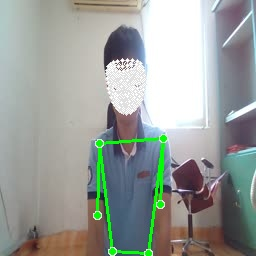

/content/holistic_results/01_38/overlay/000001.jpg


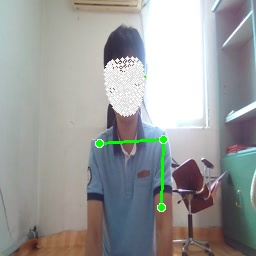

/content/holistic_results/01_38/overlay/000002.jpg


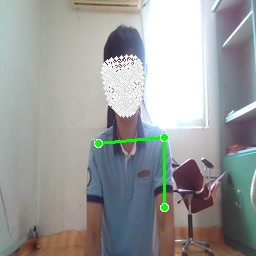

/content/holistic_results/01_38/overlay/000003.jpg


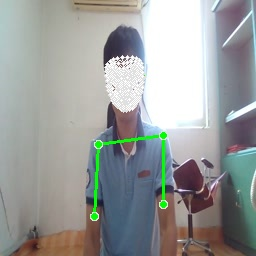

/content/holistic_results/01_38/overlay/000004.jpg


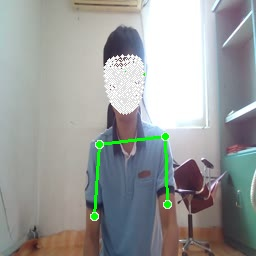

/content/holistic_results/01_38/overlay/000005.jpg


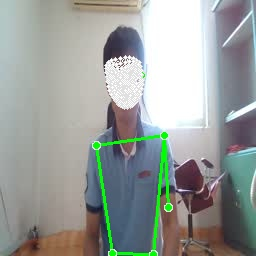

/content/holistic_results/01_38/overlay/000006.jpg


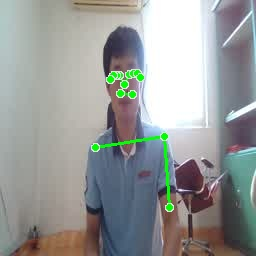

/content/holistic_results/01_38/overlay/000007.jpg


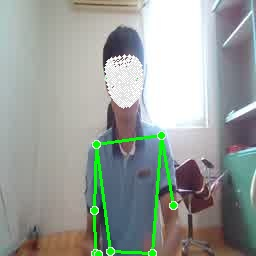

/content/holistic_results/01_38/overlay/000010.jpg


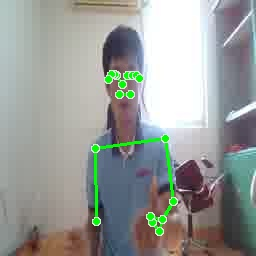

/content/holistic_results/01_38/overlay/000011.jpg


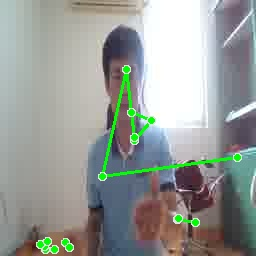

/content/holistic_results/01_38/overlay/000012.jpg


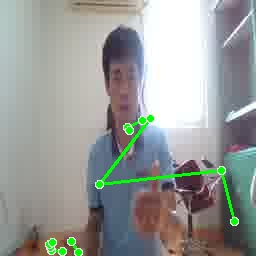

/content/holistic_results/01_38/overlay/000013.jpg


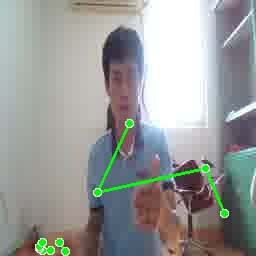

/content/holistic_results/01_38/overlay/000014.jpg


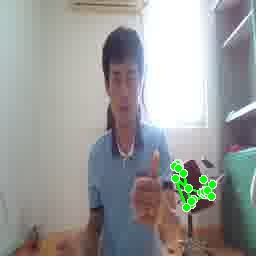

/content/holistic_results/01_38/overlay/000015.jpg


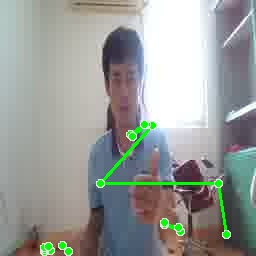

/content/holistic_results/01_38/overlay/000016.jpg


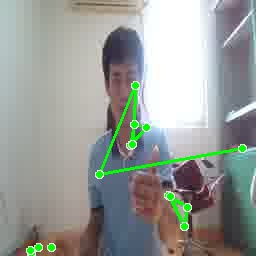

/content/holistic_results/01_38/overlay/000017.jpg


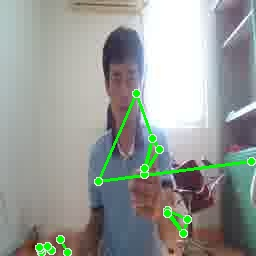

/content/holistic_results/01_38/overlay/000018.jpg


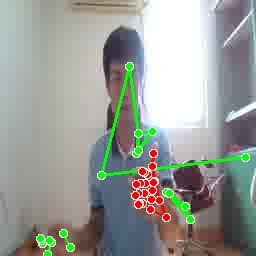

/content/holistic_results/01_38/overlay/000019.jpg


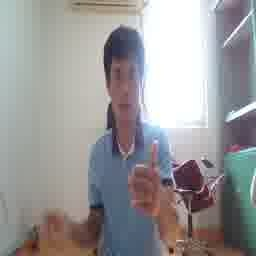

/content/holistic_results/01_38/overlay/000020.jpg


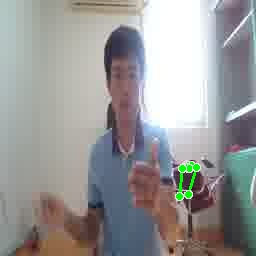

/content/holistic_results/01_38/overlay/000021.jpg


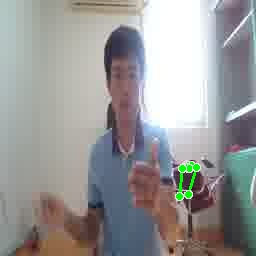

/content/holistic_results/01_38/overlay/000022.jpg


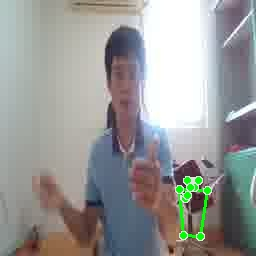

/content/holistic_results/01_38/overlay/000023.jpg


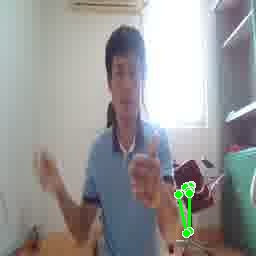

/content/holistic_results/01_38/overlay/000024.jpg


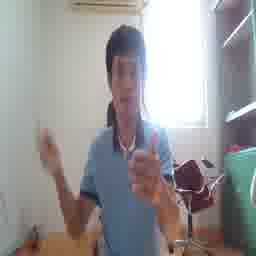

/content/holistic_results/01_38/overlay/000025.jpg


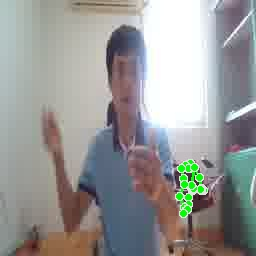

/content/holistic_results/01_38/overlay/000026.jpg


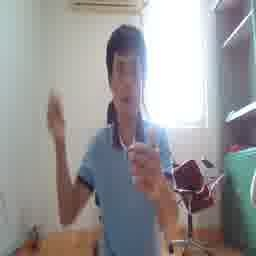

/content/holistic_results/01_38/overlay/000027.jpg


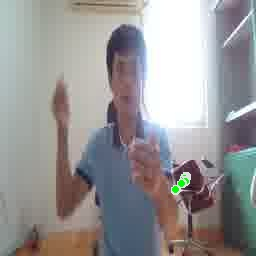

/content/holistic_results/01_38/overlay/000028.jpg


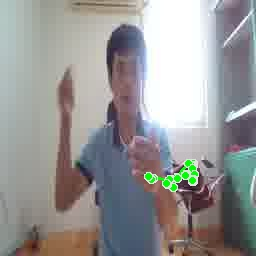

/content/holistic_results/01_38/overlay/000029.jpg


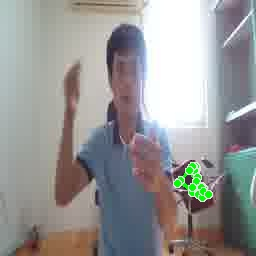

/content/holistic_results/01_38/overlay/000030.jpg


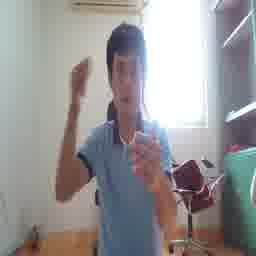

/content/holistic_results/01_38/overlay/000031.jpg


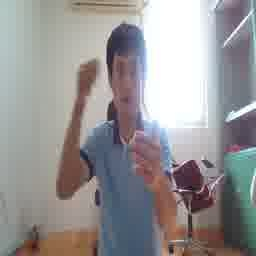

/content/holistic_results/01_38/overlay/000032.jpg


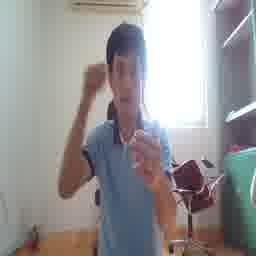

/content/holistic_results/01_38/overlay/000033.jpg


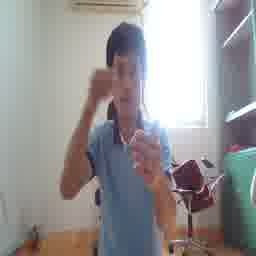

/content/holistic_results/01_38/overlay/000034.jpg


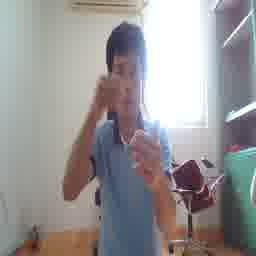

/content/holistic_results/01_38/overlay/000035.jpg


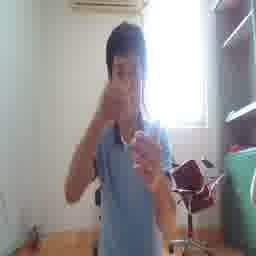

/content/holistic_results/01_38/overlay/000036.jpg


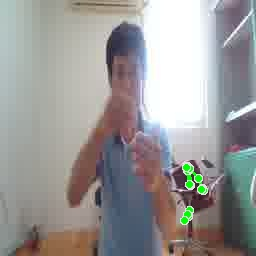

/content/holistic_results/01_38/overlay/000037.jpg


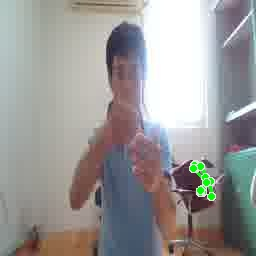

/content/holistic_results/01_38/overlay/000038.jpg


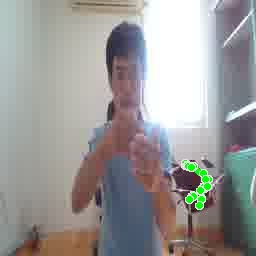

/content/holistic_results/01_38/overlay/000039.jpg


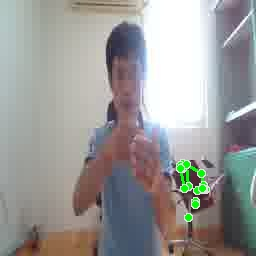

/content/holistic_results/01_38/overlay/000040.jpg


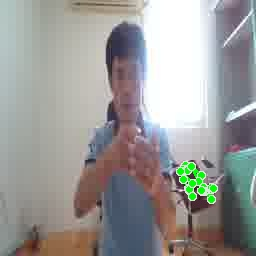

/content/holistic_results/01_38/overlay/000041.jpg


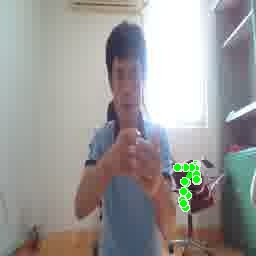

/content/holistic_results/01_38/overlay/000042.jpg


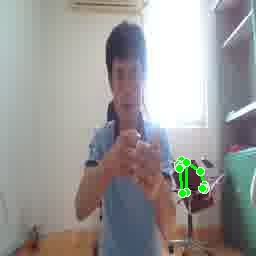

/content/holistic_results/01_38/overlay/000043.jpg


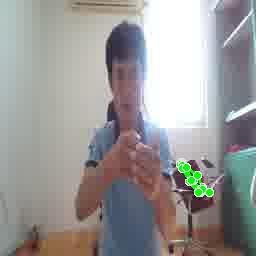

/content/holistic_results/01_38/overlay/000044.jpg


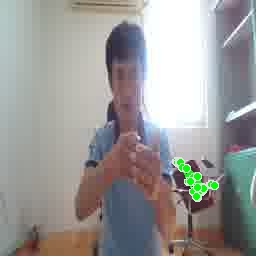

/content/holistic_results/01_38/overlay/000045.jpg


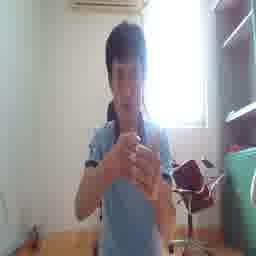

/content/holistic_results/01_38/overlay/000046.jpg


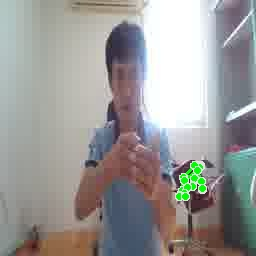

/content/holistic_results/01_38/overlay/000047.jpg


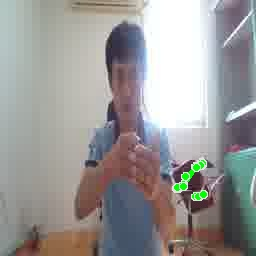

/content/holistic_results/01_38/overlay/000048.jpg


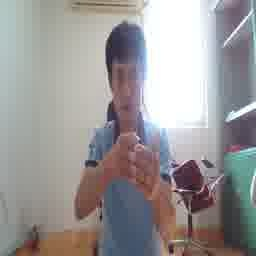

/content/holistic_results/01_38/overlay/000049.jpg


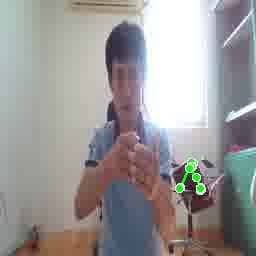

/content/holistic_results/01_38/overlay/000050.jpg


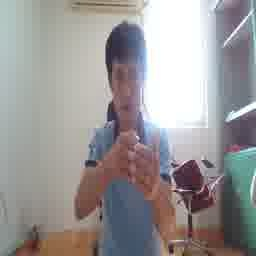

/content/holistic_results/01_38/overlay/000051.jpg


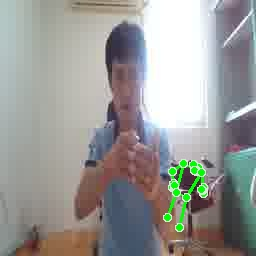

/content/holistic_results/01_38/overlay/000052.jpg


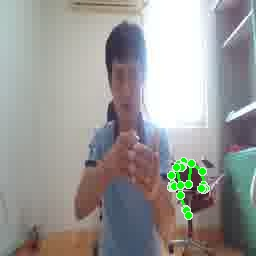

/content/holistic_results/01_38/overlay/000053.jpg


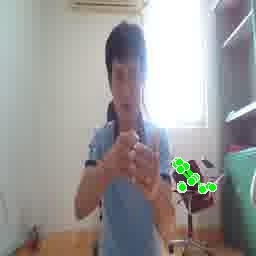

/content/holistic_results/01_38/overlay/000054.jpg


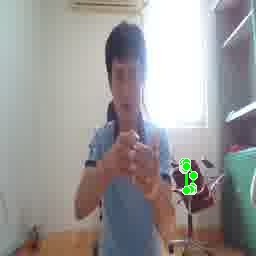

/content/holistic_results/01_38/overlay/000055.jpg


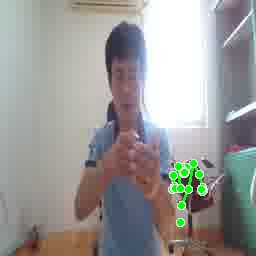

/content/holistic_results/01_38/overlay/000056.jpg


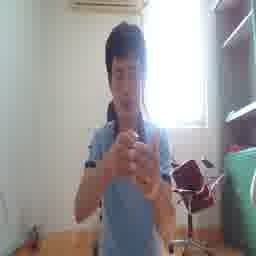

/content/holistic_results/01_38/overlay/000057.jpg


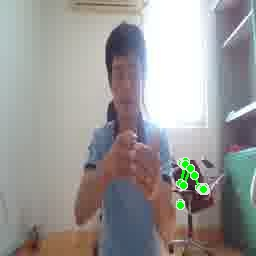

/content/holistic_results/01_38/overlay/000058.jpg


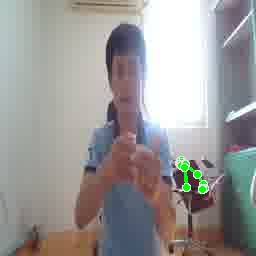

/content/holistic_results/01_38/overlay/000059.jpg


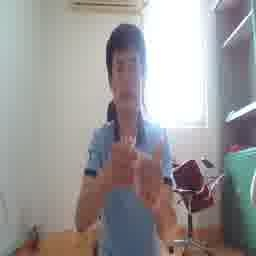

/content/holistic_results/01_38/overlay/000060.jpg


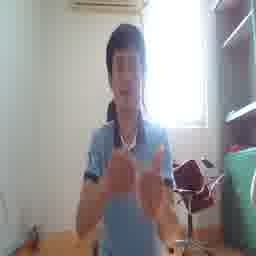

/content/holistic_results/01_38/overlay/000061.jpg


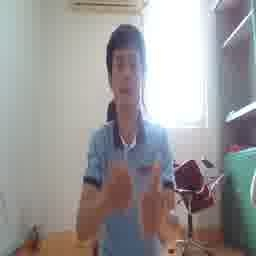

/content/holistic_results/01_38/overlay/000062.jpg


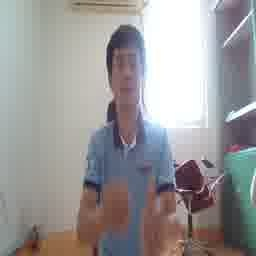

/content/holistic_results/01_38/overlay/000063.jpg


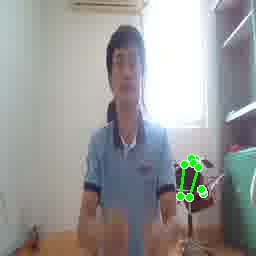

/content/holistic_results/01_38/overlay/000064.jpg


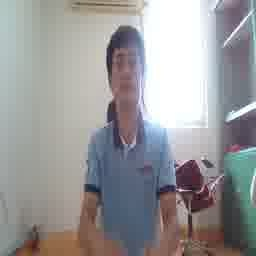

/content/holistic_results/01_38/overlay/000065.jpg


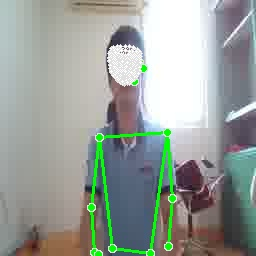

/content/holistic_results/01_38/overlay/000066.jpg


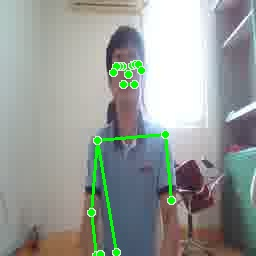

/content/holistic_results/01_38/overlay/000067.jpg


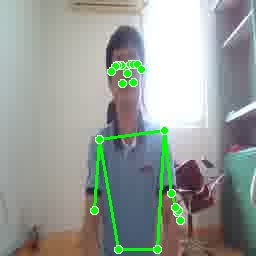

/content/holistic_results/01_38/overlay/000068.jpg


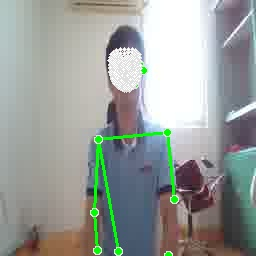

/content/holistic_results/01_38/overlay/000069.jpg


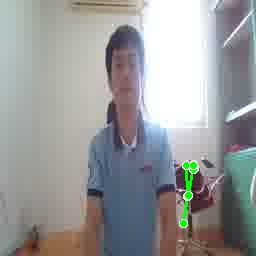

/content/holistic_results/01_38/overlay/000070.jpg


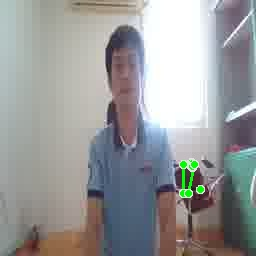

/content/holistic_results/01_38/overlay/000071.jpg


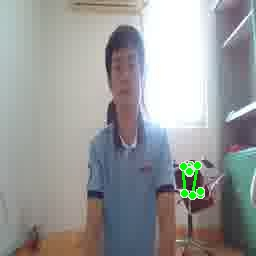

/content/holistic_results/01_38/overlay/000072.jpg


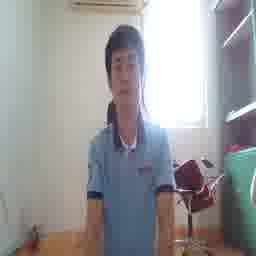

/content/holistic_results/01_38/overlay/000073.jpg


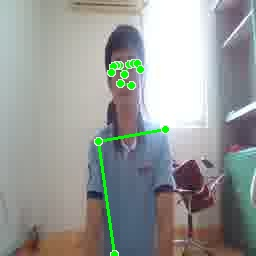

/content/holistic_results/01_38/overlay/000074.jpg


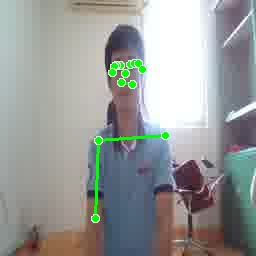

/content/holistic_results/01_38/overlay/000075.jpg


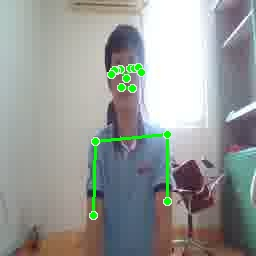

/content/holistic_results/01_38/overlay/000076.jpg


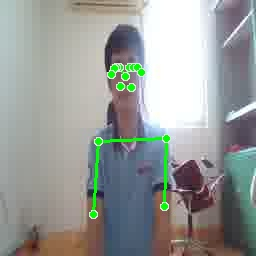

/content/holistic_results/01_38/overlay/000077.jpg


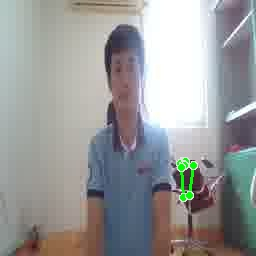

/content/holistic_results/01_38/overlay/000078.jpg


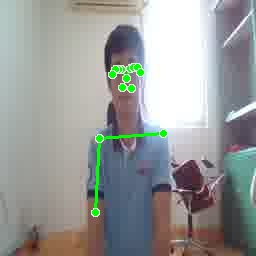

/content/holistic_results/01_38/overlay/000079.jpg


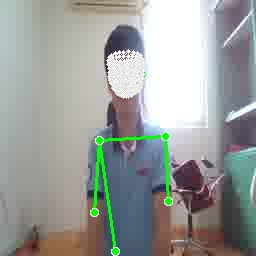

/content/holistic_results/01_38/overlay/000080.jpg


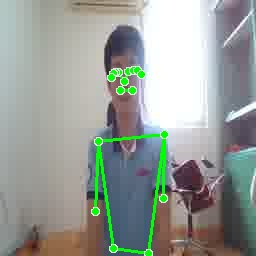

/content/holistic_results/01_38/overlay/000081.jpg


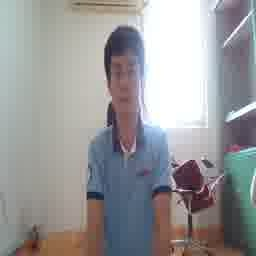

/content/holistic_results/01_38/overlay/000082.jpg


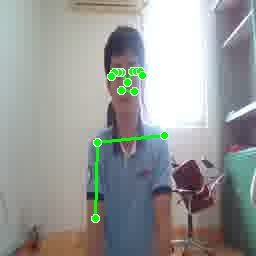

/content/holistic_results/01_38/overlay/000083.jpg


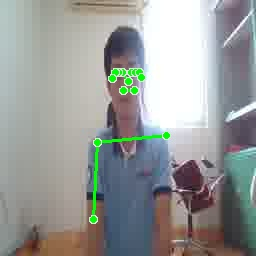

/content/holistic_results/01_38/overlay/000084.jpg


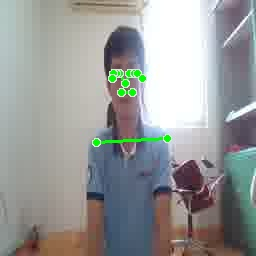

/content/holistic_results/01_38/overlay/000085.jpg


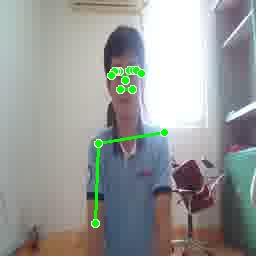

/content/holistic_results/01_38/overlay/000086.jpg


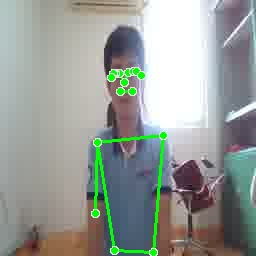

/content/holistic_results/01_38/overlay/000087.jpg


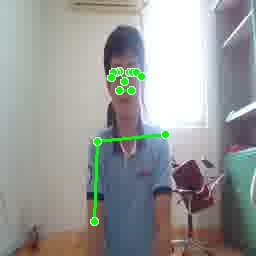

/content/holistic_results/01_38/overlay/000088.jpg


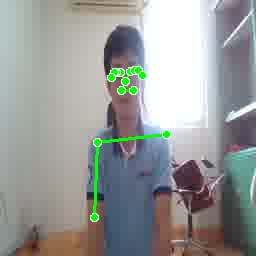

/content/holistic_results/01_38/overlay/000089.jpg


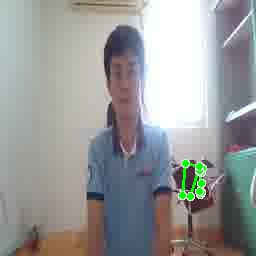

/content/holistic_results/01_38/overlay/000090.jpg


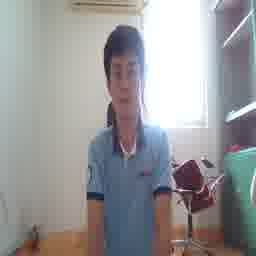

In [ ]:
sample_video = video_stats["video"].iloc[8]

# 해당 비디오 summary 가져오기
video_df = all_summary_df[all_summary_df["video"] == sample_video]

# ❗ left hand 실패한 프레임만
fail_df = video_df[
    (video_df["left_hand_detected"] == False)
    #(video_df["right_hand_detected"] == False)
]

print("num failed frames:", len(fail_df))

sample_overlay_dir = os.path.join(OUT_DIR, sample_video, "overlay")

fail_indices = fail_df["frame_idx"].values

# 너무 많으면 일부만 보기
for i in fail_indices:
    img_path = os.path.join(sample_overlay_dir, f"{i:06d}.jpg")
    print(img_path)
    img = cv2.imread(img_path)
    cv2_imshow(img)

/tmp/ipykernel_14672/1669726899.py:13: RuntimeWarning: Mean of empty slice
  jitter_per_frame = np.nanmean(diff, axis=1)


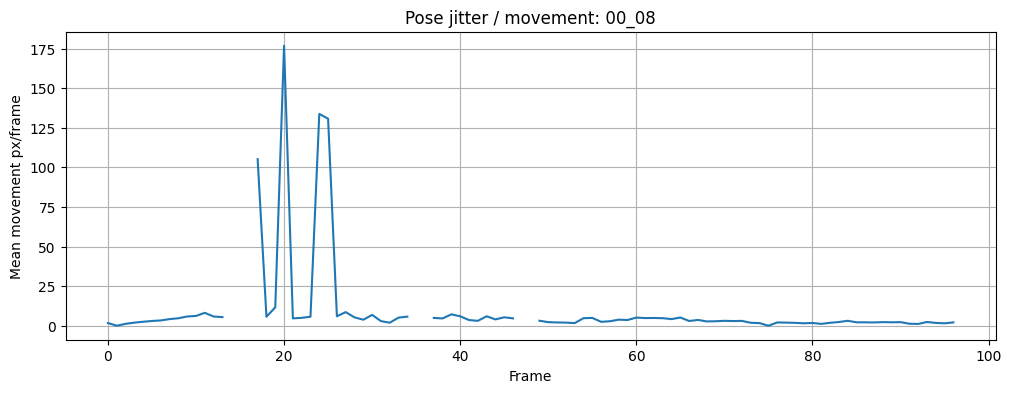

mean jitter: 9.51527


In [ ]:
# ===== pose jitter 간단 확인 =====
def compute_pose_jitter(video_name):
    pose_path = os.path.join(OUT_DIR, video_name, "pose_33.npy")
    pose = np.load(pose_path)  # (T, 33, 4)

    xy = pose[:, :, :2]
    vis = pose[:, :, 3]

    valid = (vis[1:] > 0.5) & (vis[:-1] > 0.5)
    diff = np.linalg.norm(xy[1:] - xy[:-1], axis=-1)
    diff[~valid] = np.nan

    jitter_per_frame = np.nanmean(diff, axis=1)
    return jitter_per_frame

sample_video = video_stats["video"].iloc[0]
jitter = compute_pose_jitter(sample_video)

plt.figure(figsize=(12, 4))
plt.plot(jitter)
plt.xlabel("Frame")
plt.ylabel("Mean movement px/frame")
plt.title(f"Pose jitter / movement: {sample_video}")
plt.grid(True)
plt.show()

print("mean jitter:", np.nanmean(jitter))

In [ ]:
all_summary_df.to_csv(os.path.join(OUT_DIR, "all_summary_df.csv"), index=False)
print(f"DataFrame saved to {os.path.join(OUT_DIR, 'all_summary_df.csv')}")

DataFrame saved to /content/holistic_results/all_summary_df.csv


In [ ]:
import shutil
from google.colab import files

# Zip the directory
zip_path = shutil.make_archive('/content/holistic_results_zip', 'zip', OUT_DIR)

# Download the zip file
files.download(zip_path)
print(f"Downloaded {zip_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded /content/holistic_results_zip.zip
